# Survey MLC-PA + ECC: Knowledge Graphs

Notebook này chỉ tạo **survey graph** từ file Excel `data/survey_mlc_pa_ecc.xlsx`.

Mục tiêu:

1. Chuẩn hóa danh sách bài báo trong survey.
2. Tạo concept map cho hướng MLC-PA + ECC.
3. Tạo graph liên kết bài báo với bài toán, phương pháp, loss/metric, giả định nhãn và độ phức tạp.
4. Xuất hình `.png`/`.pdf` và bảng `nodes/edges` để dùng trong survey.

Phần data graph đã được tách khỏi notebook này vì project đã có notebook/file riêng cho phân tích dữ liệu.


## 0. Cài đặt môi trường

Nếu cell import báo thiếu thư viện, chạy trong terminal của project:

```bash
pip install -r requirement.txt
```


In [ ]:
from pathlib import Path
import importlib.util
import re
import textwrap
import warnings

REQUIRED_MODULES = {
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "networkx": "networkx",
    "openpyxl": "openpyxl",
}

missing = [
    pip_name
    for module_name, pip_name in REQUIRED_MODULES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing:
    raise ImportError(
        "Thiếu thư viện: "
        + ", ".join(missing)
        + ". Hãy cài bằng: pip install -r requirement.txt"
    )

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
SURVEY_FILENAME = "survey_mlc_pa_ecc.xlsx"


def find_project_root(start=None):
    # Find the repository root from the current notebook working directory.
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "data" / SURVEY_FILENAME).exists():
            return candidate
    raise FileNotFoundError(
        f"Không tìm thấy data/{SURVEY_FILENAME}. "
        "Hãy chạy notebook từ thư mục project hoặc đặt file Excel vào thư mục data."
    )


ROOT = find_project_root()
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs" / "survey_graphs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SURVEY_XLSX = DATA_DIR / SURVEY_FILENAME


def savefig(name):
    # Save each figure as PNG and PDF for notebook viewing and paper insertion.
    stem = Path(name).stem
    png_path = OUTPUT_DIR / f"{stem}.png"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"
    plt.savefig(png_path, dpi=300)
    plt.savefig(pdf_path)
    plt.show()
    print("Saved:", png_path.relative_to(ROOT))
    print("Saved:", pdf_path.relative_to(ROOT))


print("Project root:", ROOT)
print("Survey file:", SURVEY_XLSX.relative_to(ROOT))
print("Output folder:", OUTPUT_DIR.relative_to(ROOT))

Project root: c:\Users\ADMIN\Documents\GitHub\graph01_NCKH
Survey file: data\survey_mlc_pa_ecc.xlsx
Output folder: outputs\survey_graphs


## 1. Đọc và chuẩn hóa file survey

Mỗi dòng là một bài báo. Các cột chính:

- `Nhóm`: MLC/MCC hoặc nhóm hướng nghiên cứu.
- `Tên bài báo`: node bài báo.
- `Hướng nghiên cứu`: mô tả nội dung chính.
- `Bài toán`: MLC/MCC/MDC/Label Ranking.
- `Hàm mất mát/độ đo`: loss/metric dùng để đánh giá/tối ưu.
- `Giả định nhãn`: độc lập nhãn hay mô hình hóa phụ thuộc nhãn.
- `Độ phức tạp tính toán`: gợi ý chi phí thuật toán.


In [ ]:
survey_raw = pd.read_excel(SURVEY_XLSX, sheet_name=0)
survey_df = survey_raw.dropna(subset=["Tên bài báo"]).copy()
survey_df = survey_df[survey_df["Tên bài báo"].astype(str).str.strip().ne("")]
survey_df["STT"] = pd.to_numeric(survey_df["STT"], errors="coerce").astype("Int64")
survey_df["paper_id"] = survey_df["STT"].apply(lambda x: f"P{int(x):02d}" if pd.notna(x) else "P??")

TEXT_COLS = ["Nhóm", "Tên bài báo", "Hướng nghiên cứu", "Bài toán",
             "Hàm mất mát/độ đo", "Giả định nhãn", "Độ phức tạp tính toán"]
for col in TEXT_COLS:
    survey_df[col] = survey_df[col].fillna("").astype(str).str.strip()

paper_legend = survey_df[["paper_id", "Nhóm", "Tên bài báo"]].copy()
paper_legend.to_csv(OUTPUT_DIR / "paper_legend.csv", index=False)

display(survey_df[["paper_id", "Nhóm", "Tên bài báo", "Bài toán", "Giả định nhãn", "Độ phức tạp tính toán"]])
display(paper_legend)

,paper_id,Nhóm,Tên bài báo,Bài toán,Giả định nhãn,Độ phức tạp tính toán
1,P01,MLC,A Review on Multi-Label Learning Algorithms,MLC (nhắc đến MDC qua Bayes Networks),"Tùy thuật toán (Có với cấp 1, Không với cấp cao).",Tùy thuật toán (vd: O(q⋅FB​) đến O(q2⋅FB​)).
2,P02,MLC,Bayes Optimal Multilabel Classification via Pr...,MLC,Không (Sử dụng quy tắc chuỗi xác suất).,"Rất cao, lặp toàn bộ O(2m) hoặc xấp xỉ qua Cla..."
3,P03,MLC,Discriminative Methods for Multi-Labeled Class...,MLC,Không (Khai thác tương quan nhãn).,Tương đương huấn luyện SVM đa lớp (thường là O...
4,P04,MLC,Multi label classification: An overview,MLC,"Tùy phương pháp PT (PT1, PT2 giả định độc lập).",PT3 có thể sinh ra $O(2^{|L
5,P05,MLC,Multilabel classification via calibrated label...,MLC / Label Ranking,Không (Dựa trên sở thích/so sánh từng cặp nhãn).,Cần huấn luyện O(c2) mô hình nhị phân (c là số...
6,P06,MLC,On Aggregation in Ensembles of Multilabel Clas...,MLC,"CTP/PTC-lw: Có, PTC-mode: Không.",Tỷ lệ thuận với số lượng M mô hình con trong t...
7,P07,MLC,On Label Dependence in Multi-Label Classification,MLC,Không (Nghiên cứu cách mô phỏng phụ thuộc nhãn).,Tùy mô hình base (dùng phân tích lý thuyết).
8,P08,MLC,On label dependence and loss minimization in m...,MLC,"Tùy hàm mất mát (Hamming: Có, Subset 0/1: Không).","PCC là O(2m), trong khi Binary Relevance là O(m)."
9,P09,MLC,Reliable multi-label classification: Predictio...,MLC,Có (Giả định độc lập có điều kiện - CLI).,"Khá nhanh: O(mlogm) cho Hamming/Rank, O(m2) ch..."
10,P10,MLC,Classifier chains for multi-label classification,MLC,Không (Nhãn được đưa vào làm đặc trưng cho nhã...,"Huấn luyện O(L⋅d⋅f(1,N)), gần tương đương Bina..."


In [ ]:
def problem_terms(text):
    text_l = text.lower()
    terms = []
    if "mlc" in text_l or "multi-label" in text_l or "multilabel" in text_l:
        terms.append("MLC")
    if "mcc" in text_l or "multi-class" in text_l:
        terms.append("MCC")
    if "mdc" in text_l:
        terms.append("MDC")
    if "label ranking" in text_l:
        terms.append("Label Ranking")
    return list(dict.fromkeys(terms)) or ["Khác/Chưa rõ"]


def metric_terms(text):
    aliases = {
        "average precision": "Average precision",
        "hamming": "Hamming loss",
        "subset": "Subset 0/1 loss",
        "0/1": "Subset 0/1 loss",
        "rank": "Ranking/Rank loss",
        "ranking": "Ranking/Rank loss",
        "one-error": "One-error loss",
        "f-measure": "F-measure/F1",
        "f1": "F-measure/F1",
        "precision": "Precision",
        "recall": "Recall",
        "jaccard": "Jaccard index",
        "accuracy": "Accuracy",
        "log loss": "Log loss",
    }
    text_l = text.lower()
    found = [label for key, label in aliases.items() if key in text_l]
    return list(dict.fromkeys(found)) or ["Không nêu rõ"]


def assumption_class(text):
    text_l = text.lower().strip()
    if not text_l:
        return "Không nêu rõ"
    if "tùy" in text_l:
        return "Tùy thuật toán"
    if "không" in text_l or "phụ thuộc" in text_l or "tương quan" in text_l or "chuỗi" in text_l:
        return "Mô hình hóa phụ thuộc nhãn"
    if "có" in text_l or "độc lập" in text_l or "cli" in text_l:
        return "Giả định độc lập/CLI"
    return "Không nêu rõ"


def complexity_class(text):
    text_l = text.lower().strip()
    if not text_l:
        return "Không nêu rõ"
    if "2^" in text_l or "2m" in text_l or "2l" in text_l or "hàm mũ" in text_l:
        return "Hàm mũ"
    if any(token in text_l for token in ["o(k3", "o(k2", "o(q2", "o(c2", "o(n2"]):
        return "Bậc hai/ba"
    if any(token in text_l for token in ["o(l", "o(q", "tỷ lệ thuận", "tương đương binary"]):
        return "Gần tuyến tính/theo số nhãn"
    return "Phụ thuộc mô hình base"


survey_df["problem_terms"] = survey_df["Bài toán"].apply(problem_terms)
survey_df["metric_terms"] = survey_df["Hàm mất mát/độ đo"].apply(metric_terms)
survey_df["assumption_class"] = survey_df["Giả định nhãn"].apply(assumption_class)
survey_df["complexity_class"] = survey_df["Độ phức tạp tính toán"].apply(complexity_class)
survey_df[["paper_id", "problem_terms", "metric_terms", "assumption_class", "complexity_class"]]

,paper_id,problem_terms,metric_terms,assumption_class,complexity_class
1,P01,"[MLC, MDC]","[Hamming loss, Subset 0/1 loss, Ranking/Rank l...",Tùy thuật toán,Bậc hai/ba
2,P02,[MLC],"[Hamming loss, Subset 0/1 loss, Ranking/Rank l...",Mô hình hóa phụ thuộc nhãn,Hàm mũ
3,P03,[MLC],"[Hamming loss, F-measure/F1, Precision, Recall...",Mô hình hóa phụ thuộc nhãn,Bậc hai/ba
4,P04,[MLC],"[Hamming loss, Precision, Recall, Accuracy]",Tùy thuật toán,Hàm mũ
5,P05,"[MLC, Label Ranking]","[Average precision, Hamming loss, Ranking/Rank...",Mô hình hóa phụ thuộc nhãn,Bậc hai/ba
6,P06,[MLC],"[Hamming loss, Subset 0/1 loss, F-measure/F1]",Mô hình hóa phụ thuộc nhãn,Gần tuyến tính/theo số nhãn
7,P07,[MLC],"[Hamming loss, Subset 0/1 loss, Ranking/Rank l...",Mô hình hóa phụ thuộc nhãn,Phụ thuộc mô hình base
8,P08,[MLC],"[Hamming loss, Subset 0/1 loss, Ranking/Rank l...",Tùy thuật toán,Hàm mũ
9,P09,[MLC],"[Hamming loss, Ranking/Rank loss, F-measure/F1]",Giả định độc lập/CLI,Phụ thuộc mô hình base
10,P10,[MLC],"[Hamming loss, Subset 0/1 loss, F-measure/F1, ...",Mô hình hóa phụ thuộc nhãn,Gần tuyến tính/theo số nhãn


## 2. Graph survey


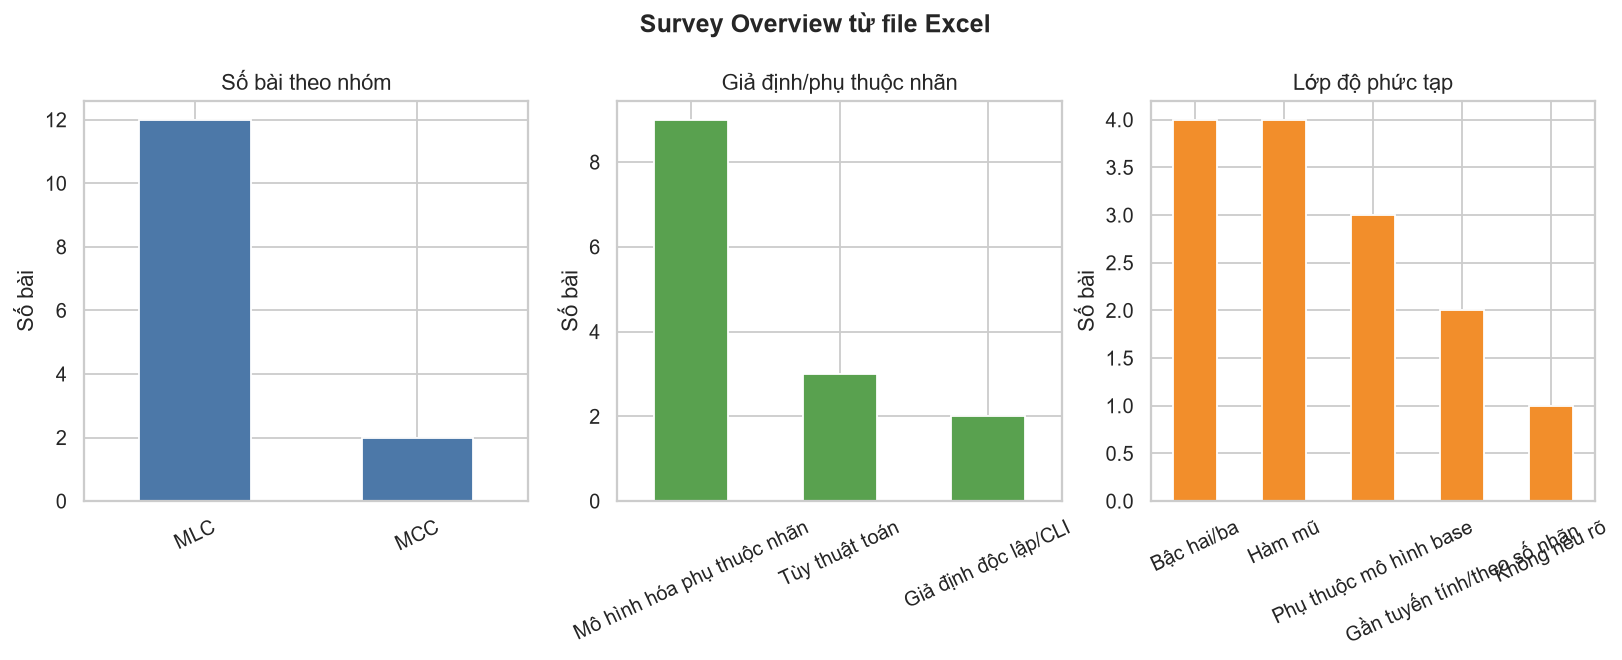

Saved: outputs\survey_graphs\01_survey_overview.png
Saved: outputs\survey_graphs\01_survey_overview.pdf


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

survey_df["Nhóm"].replace("", "Không nêu rõ").value_counts().plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Số bài theo nhóm")
axes[0].set_xlabel("")
axes[0].set_ylabel("Số bài")

survey_df["assumption_class"].value_counts().plot(kind="bar", ax=axes[1], color="#59A14F")
axes[1].set_title("Giả định/phụ thuộc nhãn")
axes[1].set_xlabel("")
axes[1].set_ylabel("Số bài")

survey_df["complexity_class"].value_counts().plot(kind="bar", ax=axes[2], color="#F28E2B")
axes[2].set_title("Lớp độ phức tạp")
axes[2].set_xlabel("")
axes[2].set_ylabel("Số bài")

for ax in axes:
    ax.tick_params(axis="x", rotation=25)
plt.suptitle("Survey Overview từ file Excel", y=1.05, fontsize=14, fontweight="bold")
savefig("01_survey_overview")

In [ ]:
PALETTE = {
    "root": "#2F4B7C",
    "group": "#4C78A8",
    "paper": "#F1CE63",
    "problem": "#E45756",
    "method": "#72B7B2",
    "metric": "#B279A2",
    "assumption": "#59A14F",
    "complexity": "#F28E2B",
    "concept": "#8CD17D",
    "data": "#BAB0AC",
}


def short_title(title, width=34, lines=2):
    title = re.sub(r"\s+", " ", str(title)).strip()
    return "\n".join(textwrap.wrap(title, width=width)[:lines])


def wrapped_label(label, width=18, lines=3):
    label = re.sub(r"\s+", " ", str(label)).strip()
    return "\n".join(textwrap.wrap(label, width=width)[:lines]) or label


def node_colors(G):
    return [PALETTE.get(G.nodes[n].get("type", "concept"), "#BAB0AC") for n in G.nodes]


def make_legend(ax, node_types):
    handles = [
        Patch(facecolor=PALETTE[t], edgecolor="white", label=t)
        for t in node_types
        if t in PALETTE
    ]
    if handles:
        ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02),
                  ncol=min(5, len(handles)), frameon=False, fontsize=9)


def draw_clean_graph(
    G,
    pos,
    title,
    filename,
    figsize=(14, 9),
    show_edge_labels=False,
    node_size=1850,
    font_size=8,
    arrows=True,
    legend_types=None,
):
    fig, ax = plt.subplots(figsize=figsize)
    colors = node_colors(G)
    degrees = dict(G.degree())
    sizes = [node_size + 80 * degrees[n] for n in G.nodes]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=colors,
        node_size=sizes,
        alpha=0.96,
        linewidths=1.0,
        edgecolors="white",
        ax=ax,
    )
    nx.draw_networkx_edges(
        G,
        pos,
        arrows=arrows and G.is_directed(),
        arrowstyle="-|>",
        arrowsize=12,
        width=1.1,
        alpha=0.36,
        edge_color="#555555",
        connectionstyle="arc3,rad=0.06",
        ax=ax,
    )
    labels = {n: wrapped_label(G.nodes[n].get("label", n), width=18, lines=3) for n in G.nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=font_size, font_weight="bold", ax=ax)

    edge_labels = nx.get_edge_attributes(G, "label")
    if show_edge_labels and edge_labels:
        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=7,
            font_color="#555555",
            rotate=False,
            alpha=0.86,
            bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "none", "alpha": 0.78},
            ax=ax,
        )

    ax.set_title(title, fontsize=15, fontweight="bold", pad=18)
    ax.axis("off")
    make_legend(ax, legend_types or sorted({G.nodes[n].get("type", "concept") for n in G.nodes}))
    savefig(filename)


def layered_positions(layers, x_gap=4.6, y_gap=1.6):
    pos = {}
    max_len = max(len(nodes) for nodes in layers if nodes)
    for x, nodes in enumerate(layers):
        n = len(nodes)
        y_start = (n - 1) * y_gap / 2
        for i, node in enumerate(nodes):
            pos[node] = (x * x_gap, y_start - i * y_gap)
    return pos


def paper_order_map():
    return {pid: i for i, pid in enumerate(survey_df["paper_id"])}


def sorted_by_survey_order(nodes):
    order = paper_order_map()
    return sorted(nodes, key=lambda n: order.get(n, 10_000))


def sorted_by_neighbor_paper_order(G, nodes):
    order = paper_order_map()

    def key(node):
        paper_neighbors = [nbr for nbr in G.neighbors(node) if nbr in order]
        if not paper_neighbors:
            return (10_000, node)
        avg_position = sum(order[nbr] for nbr in paper_neighbors) / len(paper_neighbors)
        return (avg_position, node)

    return sorted(nodes, key=key)


### 2.1 Conceptual Graph: bản đồ khái niệm MLC-PA + ECC

Graph này dùng để định vị phần lý thuyết trong survey:

- MLC là bài toán trung tâm.
- PA/PCC/Bayesian inference liên quan đến dự đoán xác suất và tối ưu loss.
- CC/ECC khai thác phụ thuộc nhãn bằng cách đưa nhãn trước vào mô hình nhãn sau.
- Pairwise association và label co-occurrence hỗ trợ giải thích vì sao cần quan tâm thứ tự chuỗi nhãn.


In [ ]:
concept_edges = [
    ("MLC", "Label Space", "có"),
    ("MLC", "Evaluation Losses", "đánh giá bởi"),
    ("MLC", "Probabilistic Prediction", "có thể mô hình hóa bằng"),
    ("Probabilistic Prediction", "Bayesian Inference", "tối ưu hóa bằng"),
    ("Bayesian Inference", "PA/PCC", "nền tảng cho"),
    ("PA/PCC", "Bayes-optimal Prediction", "hướng tới"),
    ("MLC", "Classifier Chains", "giải bằng"),
    ("Classifier Chains", "Label Dependence", "mô hình hóa"),
    ("Classifier Chains", "ECC", "mở rộng thành"),
    ("ECC", "Ensemble Aggregation", "dùng"),
    ("Label Dependence", "Pairwise Association", "đo bằng"),
    ("Pairwise Association", "Label Co-occurrence Network", "trực quan hóa thành"),
    ("Evaluation Losses", "Hamming loss", "gồm"),
    ("Evaluation Losses", "Subset 0/1 loss", "gồm"),
    ("Evaluation Losses", "F-measure/Jaccard", "gồm"),
    ("Label Co-occurrence Network", "Chain Order Design", "gợi ý"),
    ("Chain Order Design", "ECC", "hỗ trợ"),
]

G_concept = nx.DiGraph()
type_map = {
    "MLC": "root",
    "PA/PCC": "method",
    "Classifier Chains": "method",
    "ECC": "method",
    "Bayesian Inference": "concept",
    "Probabilistic Prediction": "concept",
    "Label Dependence": "concept",
    "Pairwise Association": "data",
    "Label Co-occurrence Network": "data",
    "Evaluation Losses": "metric",
    "Hamming loss": "metric",
    "Subset 0/1 loss": "metric",
    "F-measure/Jaccard": "metric",
}
for u, v, rel in concept_edges:
    G_concept.add_node(u, label=u, type=type_map.get(u, "concept"))
    G_concept.add_node(v, label=v, type=type_map.get(v, "concept"))
    G_concept.add_edge(u, v, label=rel)

concept_pos = {
    "MLC": (0, 0),
    "Label Space": (2.8, 2.8),
    "Evaluation Losses": (2.8, 0.9),
    "Probabilistic Prediction": (2.8, -0.9),
    "Classifier Chains": (2.8, -2.8),
    "Hamming loss": (5.8, 2.0),
    "Subset 0/1 loss": (5.8, 0.9),
    "F-measure/Jaccard": (5.8, -0.2),
    "Bayesian Inference": (5.8, -1.25),
    "PA/PCC": (8.8, -1.25),
    "Bayes-optimal Prediction": (11.8, -1.25),
    "Label Dependence": (5.8, -3.0),
    "ECC": (8.8, -3.0),
    "Ensemble Aggregation": (11.8, -3.0),
    "Pairwise Association": (8.8, -4.6),
    "Label Co-occurrence Network": (11.8, -4.6),
    "Chain Order Design": (14.8, -4.6),
}

draw_clean_graph(
    G_concept,
    concept_pos,
    "Conceptual Graph: MLC-PA + ECC",
    "02_conceptual_graph_mlc_pa_ecc",
    figsize=(17, 8.5),
    show_edge_labels=True,
    node_size=2100,
    font_size=8,
    legend_types=["root", "concept", "method", "metric", "data"],
)

NameError: name 'draw_clean_graph' is not defined

### 2.2 Paper-Problem Graph

Graph này nối **nhóm nghiên cứu → bài báo → bài toán** để chọn cách tổ chức Related Work.


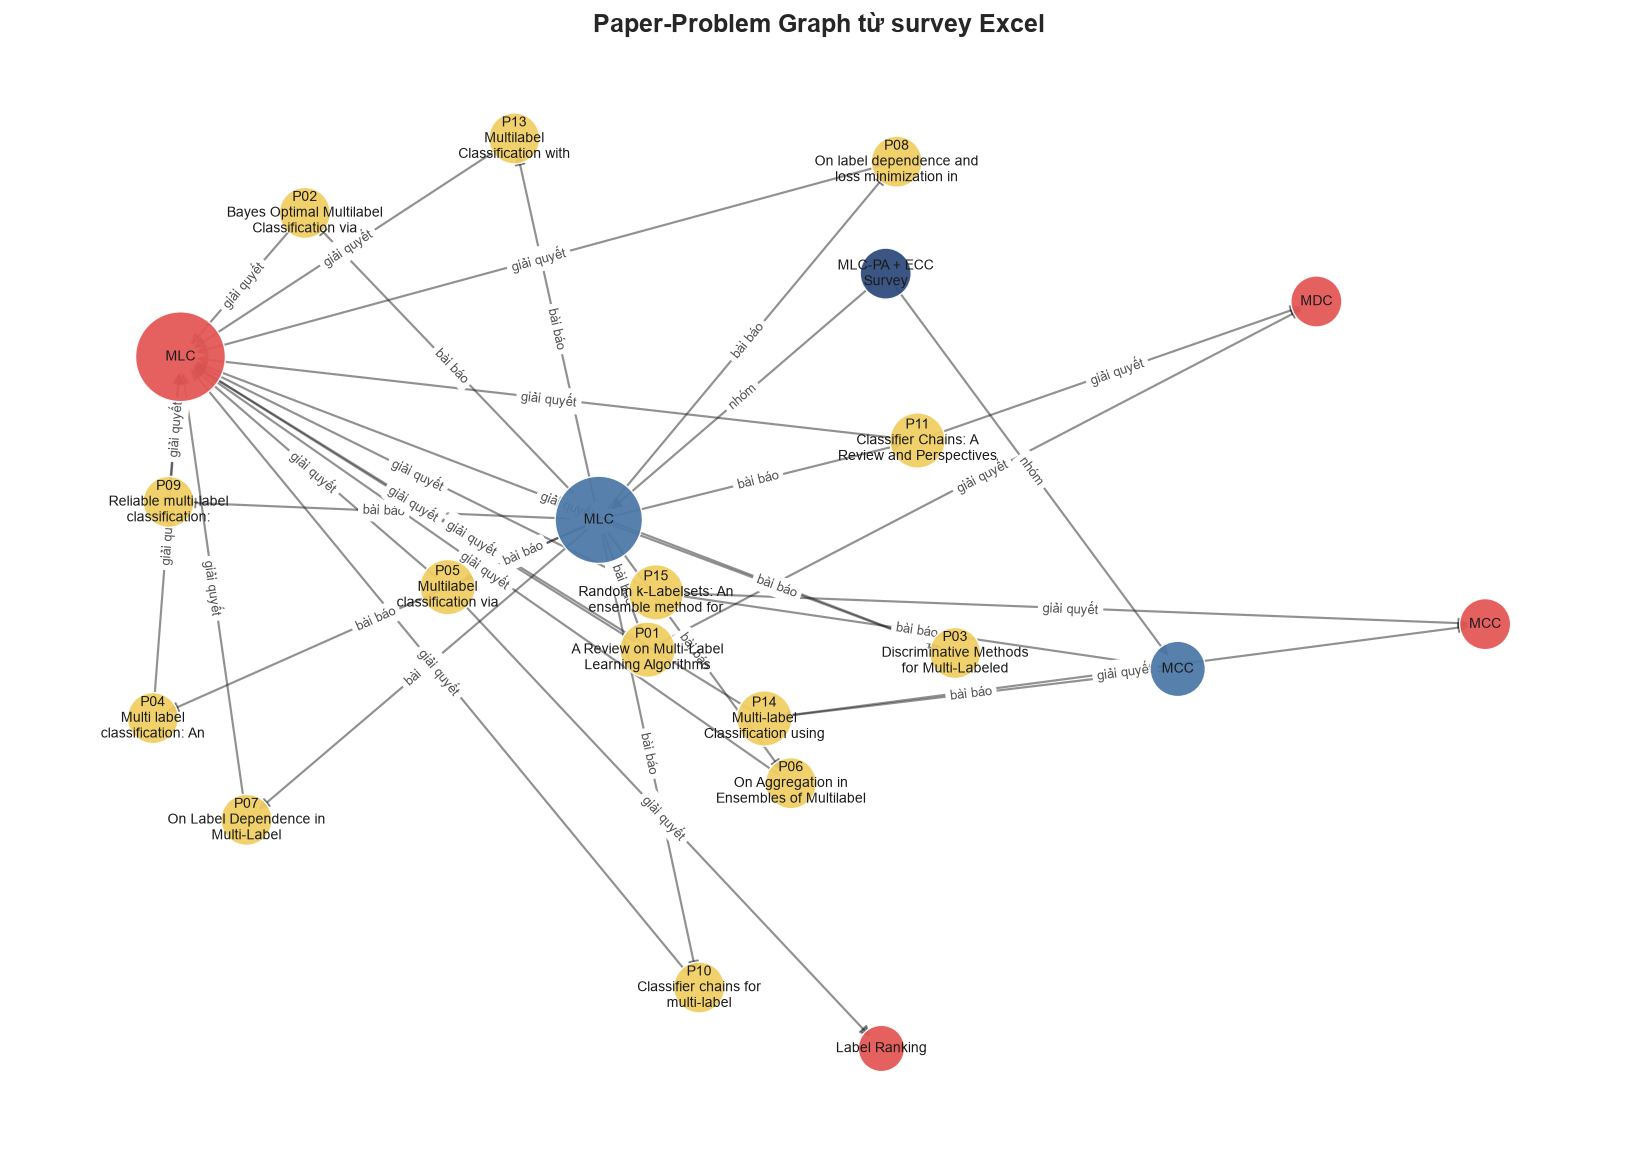

Saved: outputs\survey_graphs\03_paper_problem_graph.png
Saved: outputs\survey_graphs\03_paper_problem_graph.pdf


In [ ]:
G_problem = nx.DiGraph()
G_problem.add_node("Survey", label="MLC-PA + ECC\nSurvey", type="root")

for _, row in survey_df.iterrows():
    group = row["Nhóm"] or "Không nêu rõ"
    paper = row["paper_id"]
    G_problem.add_node(group, label=group, type="group")
    G_problem.add_node(paper, label=paper, type="paper")
    G_problem.add_edge("Survey", group, label="gồm nhóm")
    G_problem.add_edge(group, paper, label="thuộc nhóm")
    for p in row["problem_terms"]:
        problem_node = f"Problem: {p}"
        G_problem.add_node(problem_node, label=p, type="problem")
        G_problem.add_edge(paper, problem_node, label="giải quyết")

problem_layers = [
    ["Survey"],
    sorted([n for n, d in G_problem.nodes(data=True) if d.get("type") == "group"]),
    sorted_by_survey_order([n for n, d in G_problem.nodes(data=True) if d.get("type") == "paper"]),
    sorted_by_neighbor_paper_order(G_problem, [n for n, d in G_problem.nodes(data=True) if d.get("type") == "problem"]),
]
problem_pos = layered_positions(problem_layers, x_gap=4.4, y_gap=1.25)

draw_clean_graph(
    G_problem,
    problem_pos,
    "Paper-Problem Graph từ survey Excel",
    "03_paper_problem_graph",
    figsize=(16, 13),
    show_edge_labels=True,
    node_size=1550,
    font_size=8,
    legend_types=["root", "group", "paper", "problem"],
)


### 2.3 Paper-Method/Keyword Graph

Graph này gom bài báo theo từ khóa phương pháp. Các node có degree cao là điểm neo để viết mạch survey.


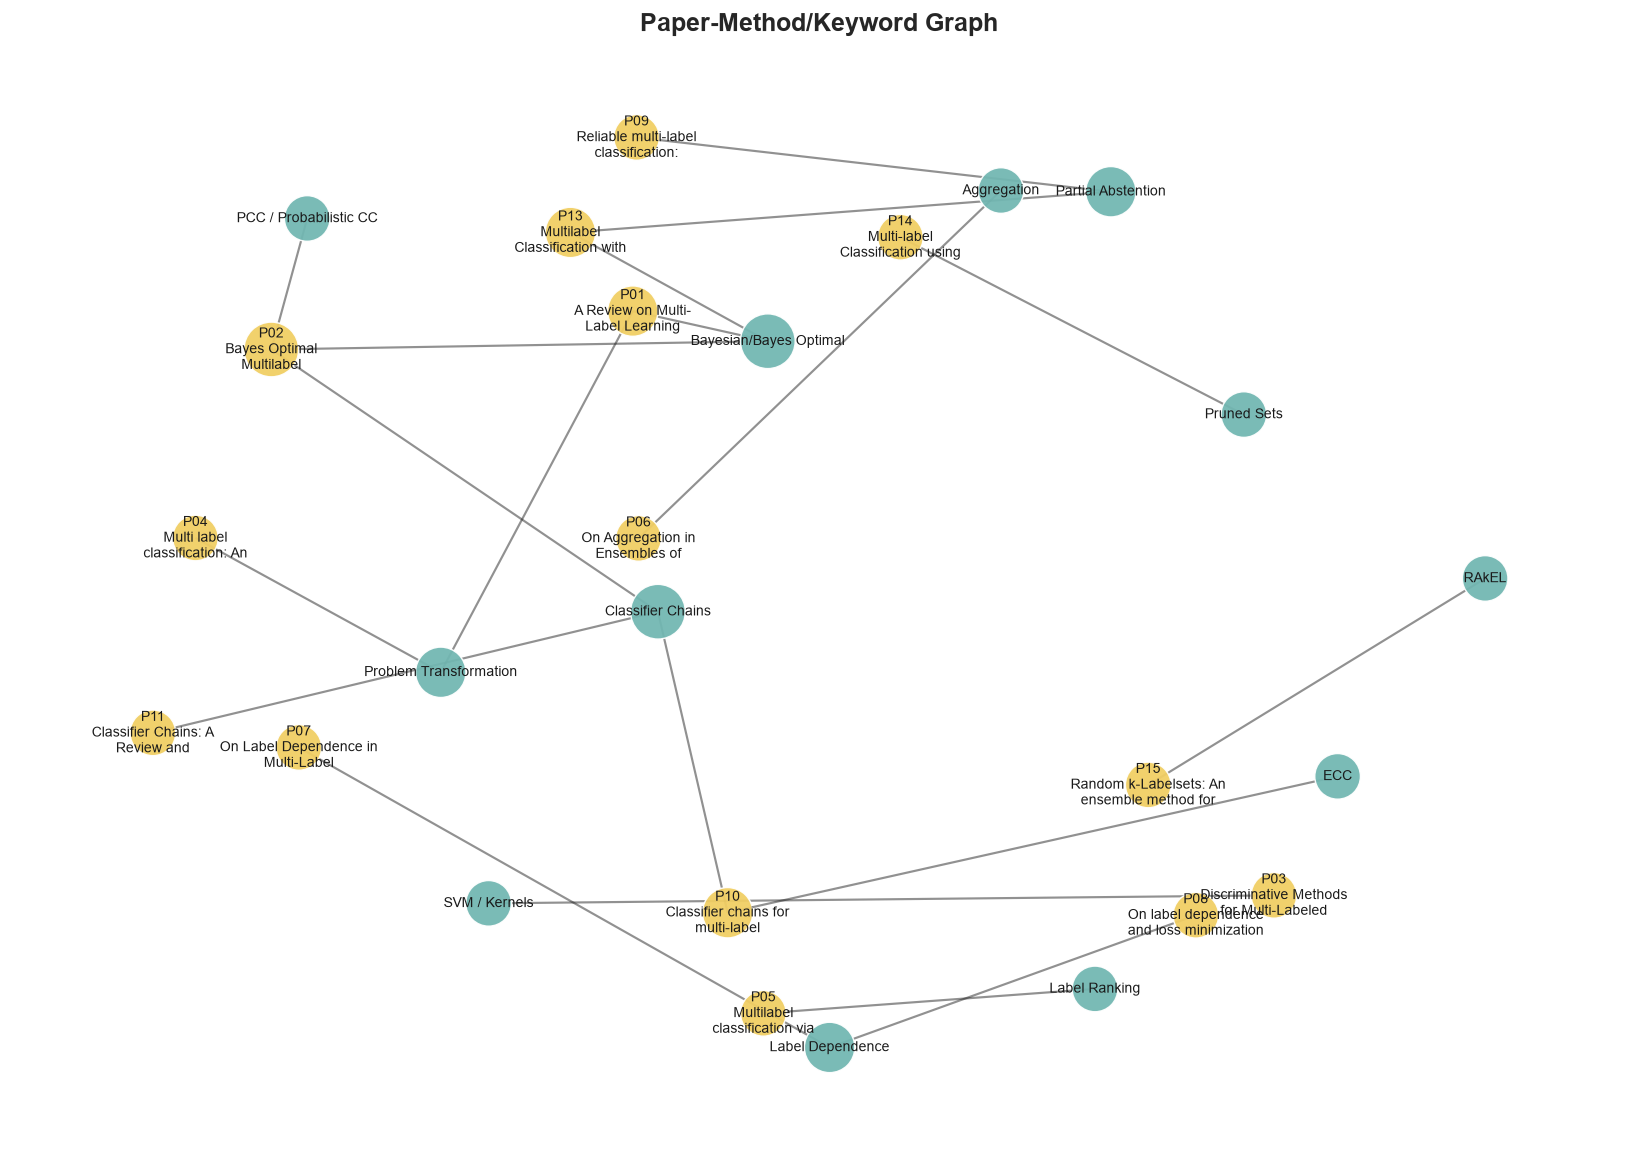

Saved: outputs\survey_graphs\04_paper_method_keyword_graph.png
Saved: outputs\survey_graphs\04_paper_method_keyword_graph.pdf


,Keyword,Degree
0,Bayesian/Bayes Optimal,3
2,Classifier Chains,3
1,Problem Transformation,2
7,Label Dependence,2
8,Partial Abstention,2
3,PCC / Probabilistic CC,1
5,Label Ranking,1
4,SVM / Kernels,1
6,Aggregation,1
9,ECC,1


In [ ]:
KEYWORD_PATTERNS = {
    "Classifier Chains": r"classifier chains|\bcc\b",
    "ECC": r"ensemble of classifier chains|\becc\b",
    "PCC / Probabilistic CC": r"probabilistic classifier chains|\bpcc\b|probabilistic cc",
    "Bayesian/Bayes Optimal": r"bayes|bayesian",
    "Label Ranking": r"label ranking|calibrated label ranking",
    "Label Dependence": r"label dependence|correlation|tương quan|phụ thuộc",
    "SVM / Kernels": r"svm|kernel",
    "Aggregation": r"aggregation|gộp",
    "Pruned Sets": r"pruned sets",
    "RAkEL": r"random k-labelsets|rakel",
    "Partial Abstention": r"abstention|từ chối",
    "Problem Transformation": r"problem transformation|\bpt\b",
}

G_method = nx.Graph()
for _, row in survey_df.iterrows():
    paper = row["paper_id"]
    text = " ".join([row["Tên bài báo"], row["Hướng nghiên cứu"], row["Bài toán"]]).lower()
    G_method.add_node(paper, label=paper, type="paper")
    matched = 0
    for keyword, pattern in KEYWORD_PATTERNS.items():
        if re.search(pattern, text, flags=re.IGNORECASE):
            G_method.add_node(keyword, label=keyword, type="method")
            G_method.add_edge(paper, keyword, label="đề cập")
            matched += 1
    if matched == 0:
        G_method.add_node("Other/Survey", label="Other/Survey", type="method")
        G_method.add_edge(paper, "Other/Survey", label="khảo sát")

method_nodes = sorted_by_neighbor_paper_order(
    G_method,
    [n for n, d in G_method.nodes(data=True) if d.get("type") == "method"],
)
method_layers = [
    sorted_by_survey_order([n for n, d in G_method.nodes(data=True) if d.get("type") == "paper"]),
    method_nodes,
]
method_pos = layered_positions(method_layers, x_gap=6.8, y_gap=1.05)

draw_clean_graph(
    G_method,
    method_pos,
    "Paper-Method/Keyword Graph",
    "04_paper_method_keyword_graph",
    figsize=(16, 13),
    show_edge_labels=True,
    node_size=1500,
    font_size=8,
    arrows=False,
    legend_types=["paper", "method"],
)

method_degree = (
    pd.DataFrame([
        {"Keyword": n, "Degree": G_method.degree(n)}
        for n, data in G_method.nodes(data=True)
        if data.get("type") == "method"
    ])
    .sort_values("Degree", ascending=False)
)
method_degree.to_csv(OUTPUT_DIR / "04_method_keyword_degree.csv", index=False)
method_degree


### 2.4 Loss/Metric Graph

Graph này nối bài báo với loss/metric. Nó giúp viết phần đánh giá thuật toán: Hamming loss, Subset 0/1 loss, F-measure, Jaccard, Ranking loss,...


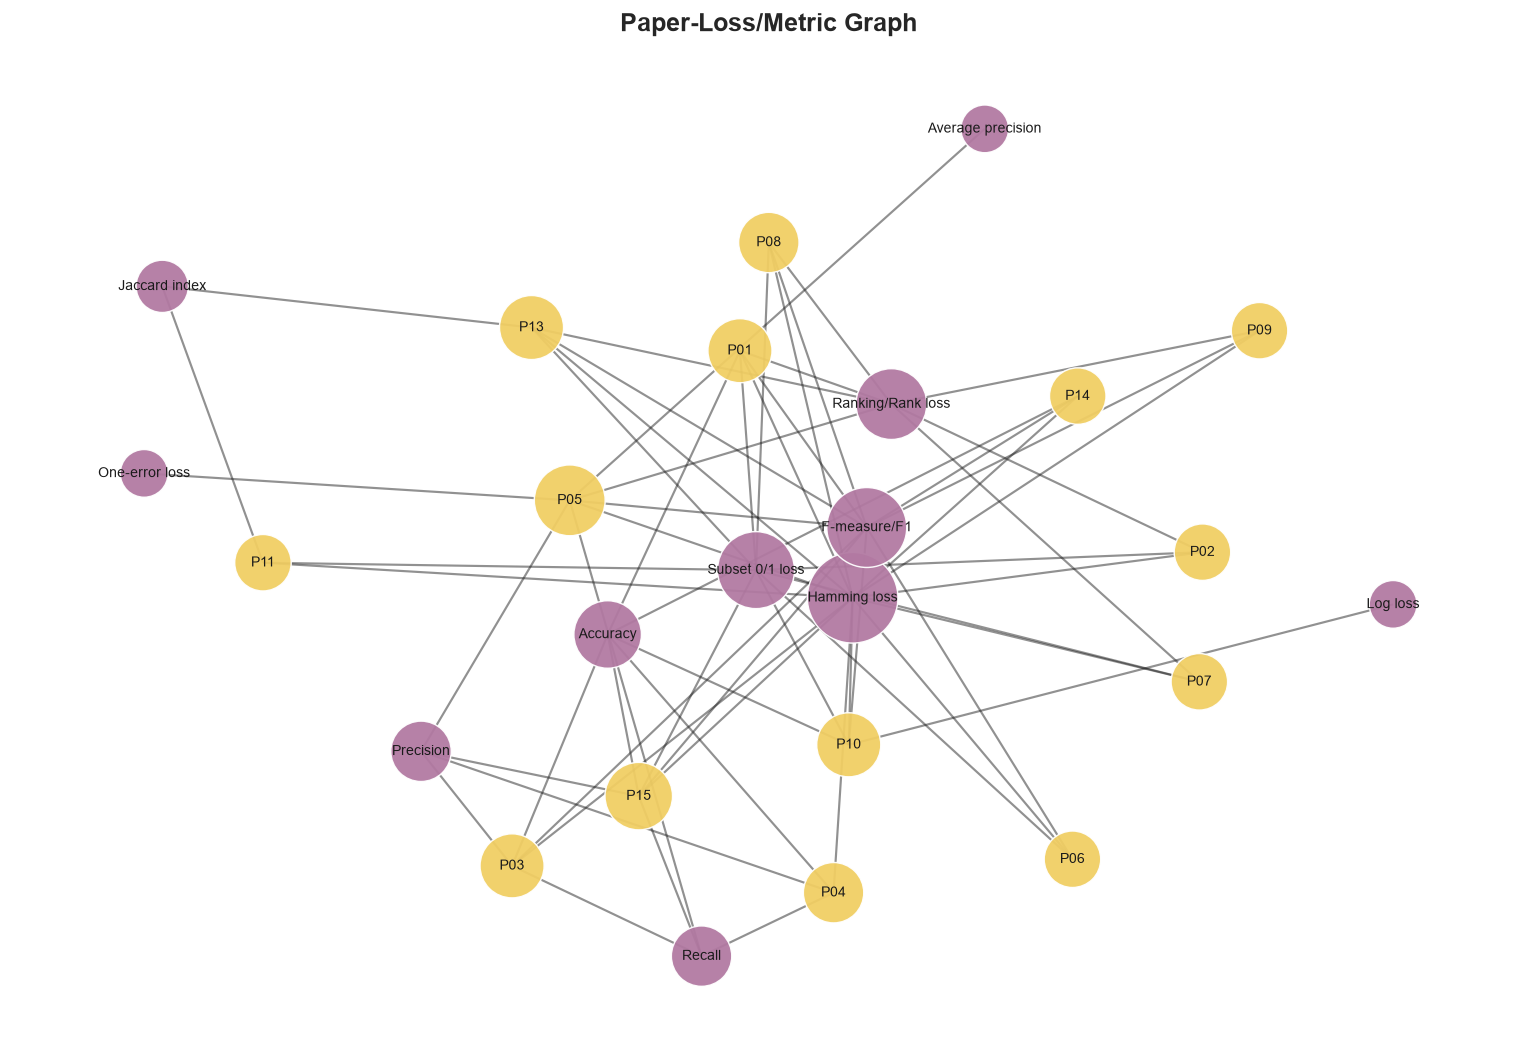

Saved: outputs\survey_graphs\05_paper_metric_graph.png
Saved: outputs\survey_graphs\05_paper_metric_graph.pdf


,Metric/Loss,Papers
0,Hamming loss,14
3,F-measure/F1,10
1,Subset 0/1 loss,9
2,Ranking/Rank loss,7
4,Accuracy,6
5,Precision,4
6,Recall,4
10,Jaccard index,2
7,Average precision,1
8,One-error loss,1


In [ ]:
G_metric = nx.Graph()
for _, row in survey_df.iterrows():
    paper = row["paper_id"]
    G_metric.add_node(paper, label=paper, type="paper")
    for metric in row["metric_terms"]:
        G_metric.add_node(metric, label=metric, type="metric")
        G_metric.add_edge(paper, metric, label="đánh giá")

metric_degree = (
    pd.DataFrame([
        {"Metric/Loss": n, "Papers": G_metric.degree(n)}
        for n, data in G_metric.nodes(data=True)
        if data.get("type") == "metric"
    ])
    .sort_values(["Papers", "Metric/Loss"], ascending=[False, True])
)
metric_degree.to_csv(OUTPUT_DIR / "05_metric_degree.csv", index=False)

paper_ids = list(survey_df["paper_id"])
metrics = list(metric_degree["Metric/Loss"])
metric_matrix = pd.DataFrame(0, index=paper_ids, columns=metrics)

for _, row in survey_df.iterrows():
    for metric in row["metric_terms"]:
        metric_matrix.loc[row["paper_id"], metric] = 1

metric_matrix.to_csv(OUTPUT_DIR / "05_paper_metric_matrix.csv")

plt.figure(figsize=(13.5, 8.5))
ax = sns.heatmap(
    metric_matrix,
    cmap=sns.color_palette(["#F8F8F8", "#B279A2"]),
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    square=False,
)
ax.set_title("Paper-Metric Matrix", fontsize=15, fontweight="bold", pad=16)
ax.set_xlabel("Loss / Metric")
ax.set_ylabel("Paper ID")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)

for text in ax.get_xticklabels():
    text.set_ha("right")

savefig("05_paper_metric_graph")
metric_degree


### 2.5 Ma trận giả định nhãn và độ phức tạp

Graph này giúp so sánh trade-off: phương pháp mô hình hóa phụ thuộc nhãn thường giàu biểu diễn hơn nhưng có thể tốn chi phí hơn.


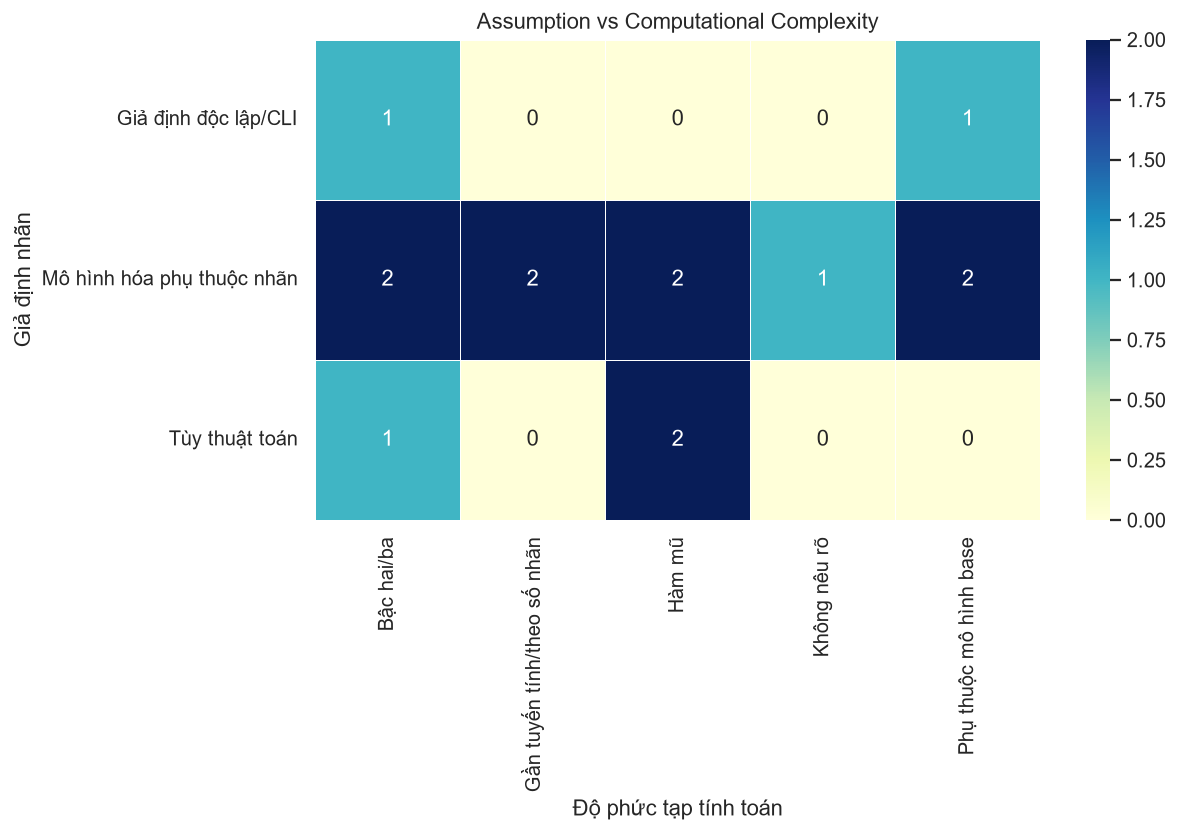

Saved: outputs\survey_graphs\06_assumption_complexity_matrix.png
Saved: outputs\survey_graphs\06_assumption_complexity_matrix.pdf


complexity_class,Bậc hai/ba,Gần tuyến tính/theo số nhãn,Hàm mũ,Không nêu rõ,Phụ thuộc mô hình base
assumption_class,,,,,
Giả định độc lập/CLI,1,0,0,0,1
Mô hình hóa phụ thuộc nhãn,2,2,2,1,2
Tùy thuật toán,1,0,2,0,0


In [ ]:
matrix = pd.crosstab(survey_df["assumption_class"], survey_df["complexity_class"])
plt.figure(figsize=(10.5, 5.2))
ax = sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.7, linecolor="white")
ax.set_title("Assumption vs Computational Complexity", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Độ phức tạp tính toán")
ax.set_ylabel("Giả định nhãn")
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", rotation=0)
savefig("06_assumption_complexity_matrix")
matrix


### 2.6 Xuất bảng nodes/edges cho survey graph

Các bảng này lưu lại node, edge và từ khóa quan hệ trên cạnh. Có thể dùng lại trong Gephi, Cytoscape, Obsidian hoặc phần phụ lục.


In [ ]:
def graph_to_tables(G, graph_name):
    nodes = pd.DataFrame([
        {
            "graph": graph_name,
            "node_id": n,
            "label": data.get("label", n),
            "type": data.get("type", ""),
            "degree": G.degree(n),
        }
        for n, data in G.nodes(data=True)
    ])
    edges = pd.DataFrame([
        {
            "graph": graph_name,
            "source": u,
            "target": v,
            "relation": data.get("label", ""),
            "weight": data.get("weight", 1),
        }
        for u, v, data in G.edges(data=True)
    ])
    return nodes, edges


node_tables, edge_tables = [], []
for name, graph in {
    "concept": G_concept,
    "paper_problem": G_problem,
    "paper_method": G_method,
    "paper_metric": G_metric,
}.items():
    n, e = graph_to_tables(graph, name)
    node_tables.append(n)
    edge_tables.append(e)

survey_nodes = pd.concat(node_tables, ignore_index=True)
survey_edges = pd.concat(edge_tables, ignore_index=True)
survey_nodes.to_csv(OUTPUT_DIR / "survey_graph_nodes.csv", index=False)
survey_edges.to_csv(OUTPUT_DIR / "survey_graph_edges.csv", index=False)

display(survey_nodes.head())
display(survey_edges.head())


## 3. Gợi ý đưa graph vào survey

1. Dùng `02_conceptual_graph_mlc_pa_ecc` ở phần mở đầu/lý thuyết để giải thích vị trí PA, CC và ECC.
2. Dùng `03_paper_problem_graph` và `04_paper_method_keyword_graph` trong Related Work để chia luồng nghiên cứu.
3. Dùng `05_paper_metric_graph` khi bàn về loss/metric đánh giá thuật toán.
4. Dùng `06_assumption_complexity_matrix` để so sánh giả định nhãn và trade-off độ phức tạp.
5. Dùng `paper_legend.csv` để tra tên đầy đủ của các node `P01`, `P02`, ...
6. Dùng `survey_graph_nodes.csv` và `survey_graph_edges.csv` nếu muốn đưa graph sang Gephi/Cytoscape/Obsidian.

Lưu ý: file Excel hiện chưa có cột trích dẫn trực tiếp giữa các bài báo, nên notebook này chưa dựng Citation Network thật. Nếu bổ sung cột `Cites` hoặc `References`, có thể thêm graph trích dẫn sau.
